# without using Binning

In [1]:

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('titanic.csv')[['Age','Fare','SibSp','Parch','Survived']]
df.head(2)

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1


In [3]:
df.dropna(inplace=True)

In [4]:
df.isnull().sum()

Age         0
Fare        0
SibSp       0
Parch       0
Survived    0
dtype: int64

In [5]:
df['family'] = df['SibSp'] + df['Parch']

In [6]:
df.drop(columns=['SibSp','Parch'], inplace=True)

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train.shape

(571, 3)

In [9]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

# After using BInning 
Advantages of Binning

✅ Reduces overfitting
✅ Handles noisy data
✅ Helps linear models
✅ Easier interpretation
✅ Useful in feature engineering

In [10]:
age_binning=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile',random_state=42)
fare_binning=KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile',random_state=42)

In [11]:
tramsform=ColumnTransformer(transformers=[
    ('age', age_binning , [0]),
    ('fare', fare_binning , [1])
],remainder='passthrough')

In [12]:
x_train_trf=tramsform.fit_transform(X_train)
x_test_trf=tramsform.transform(X_test)

In [13]:
tramsform.named_transformers_['age'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [14]:
clf.fit(x_train_trf,y_train)
y_pred=clf.predict(x_test_trf)

In [15]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [16]:
x_train_trf.shape

(571, 3)

Text(0.5, 1.02, 'After')

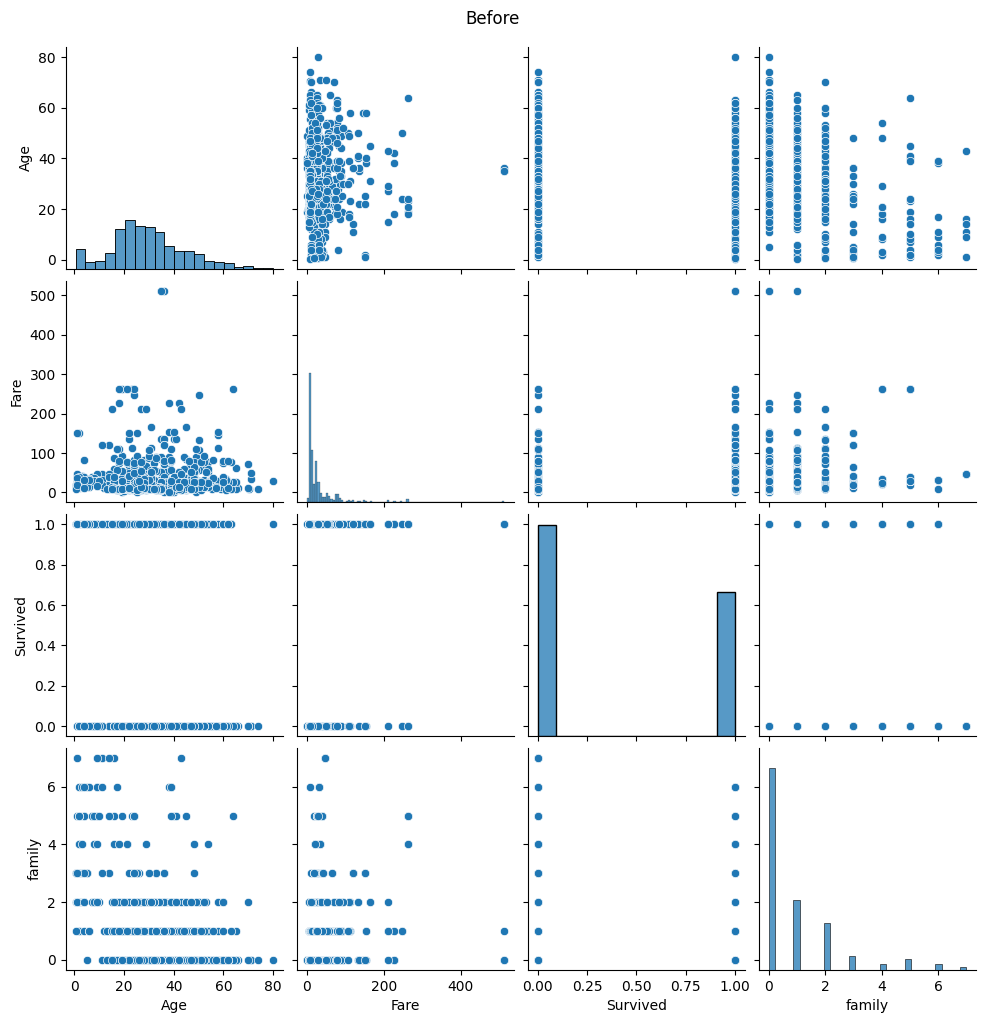

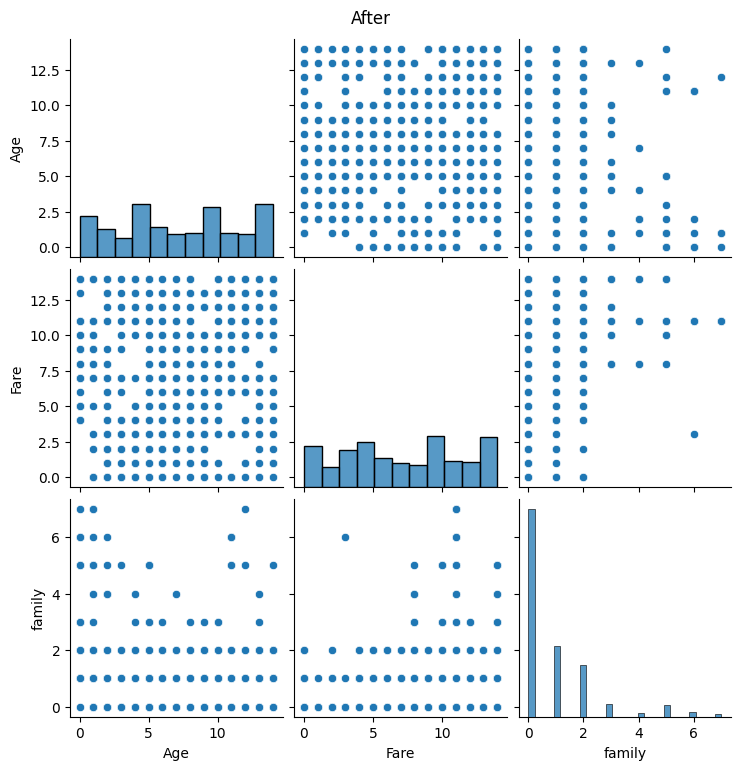

In [19]:
import pandas as pd
import seaborn as sns

df_binned = pd.DataFrame(
    x_train_trf,
    columns=['Age','Fare','family']
)
sns.pairplot(df)
plt.suptitle("Before", y=1.02)

sns.pairplot(df_binned)
plt.suptitle("After", y=1.02)

#### conclusion :
##### here, we cam clearly visualize the shape of data. we see Agfe and Fare column are normally distributed due to binning and Family is not. before binning Age , Fare and Family are highly skewed and not normally distributed. Also Accuracy score increased